In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import default_rng
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [16]:
df = pd.read_csv("carnitines_deltas_dataset.tsv", sep="\t")

In [17]:
len(df['dataset'].unique())

707

In [18]:
df

,scan_library,cluster,dataset,delta_round_test
0,1,25,MSV000083526,-18.04
1,1,25,MSV000081118,-18.04
2,1,25,MSV000081118,-18.04
3,1,25,MSV000081118,-18.04
4,1,25,MSV000083538,-18.04
...,...,...,...,...
1214769,34222,37210,MSV000091363,781.56
1214770,34222,37210,MSV000091363,781.56
1214771,34222,37210,MSV000091363,781.56
1214772,34222,37210,MSV000091007,781.56


N datasets: 707


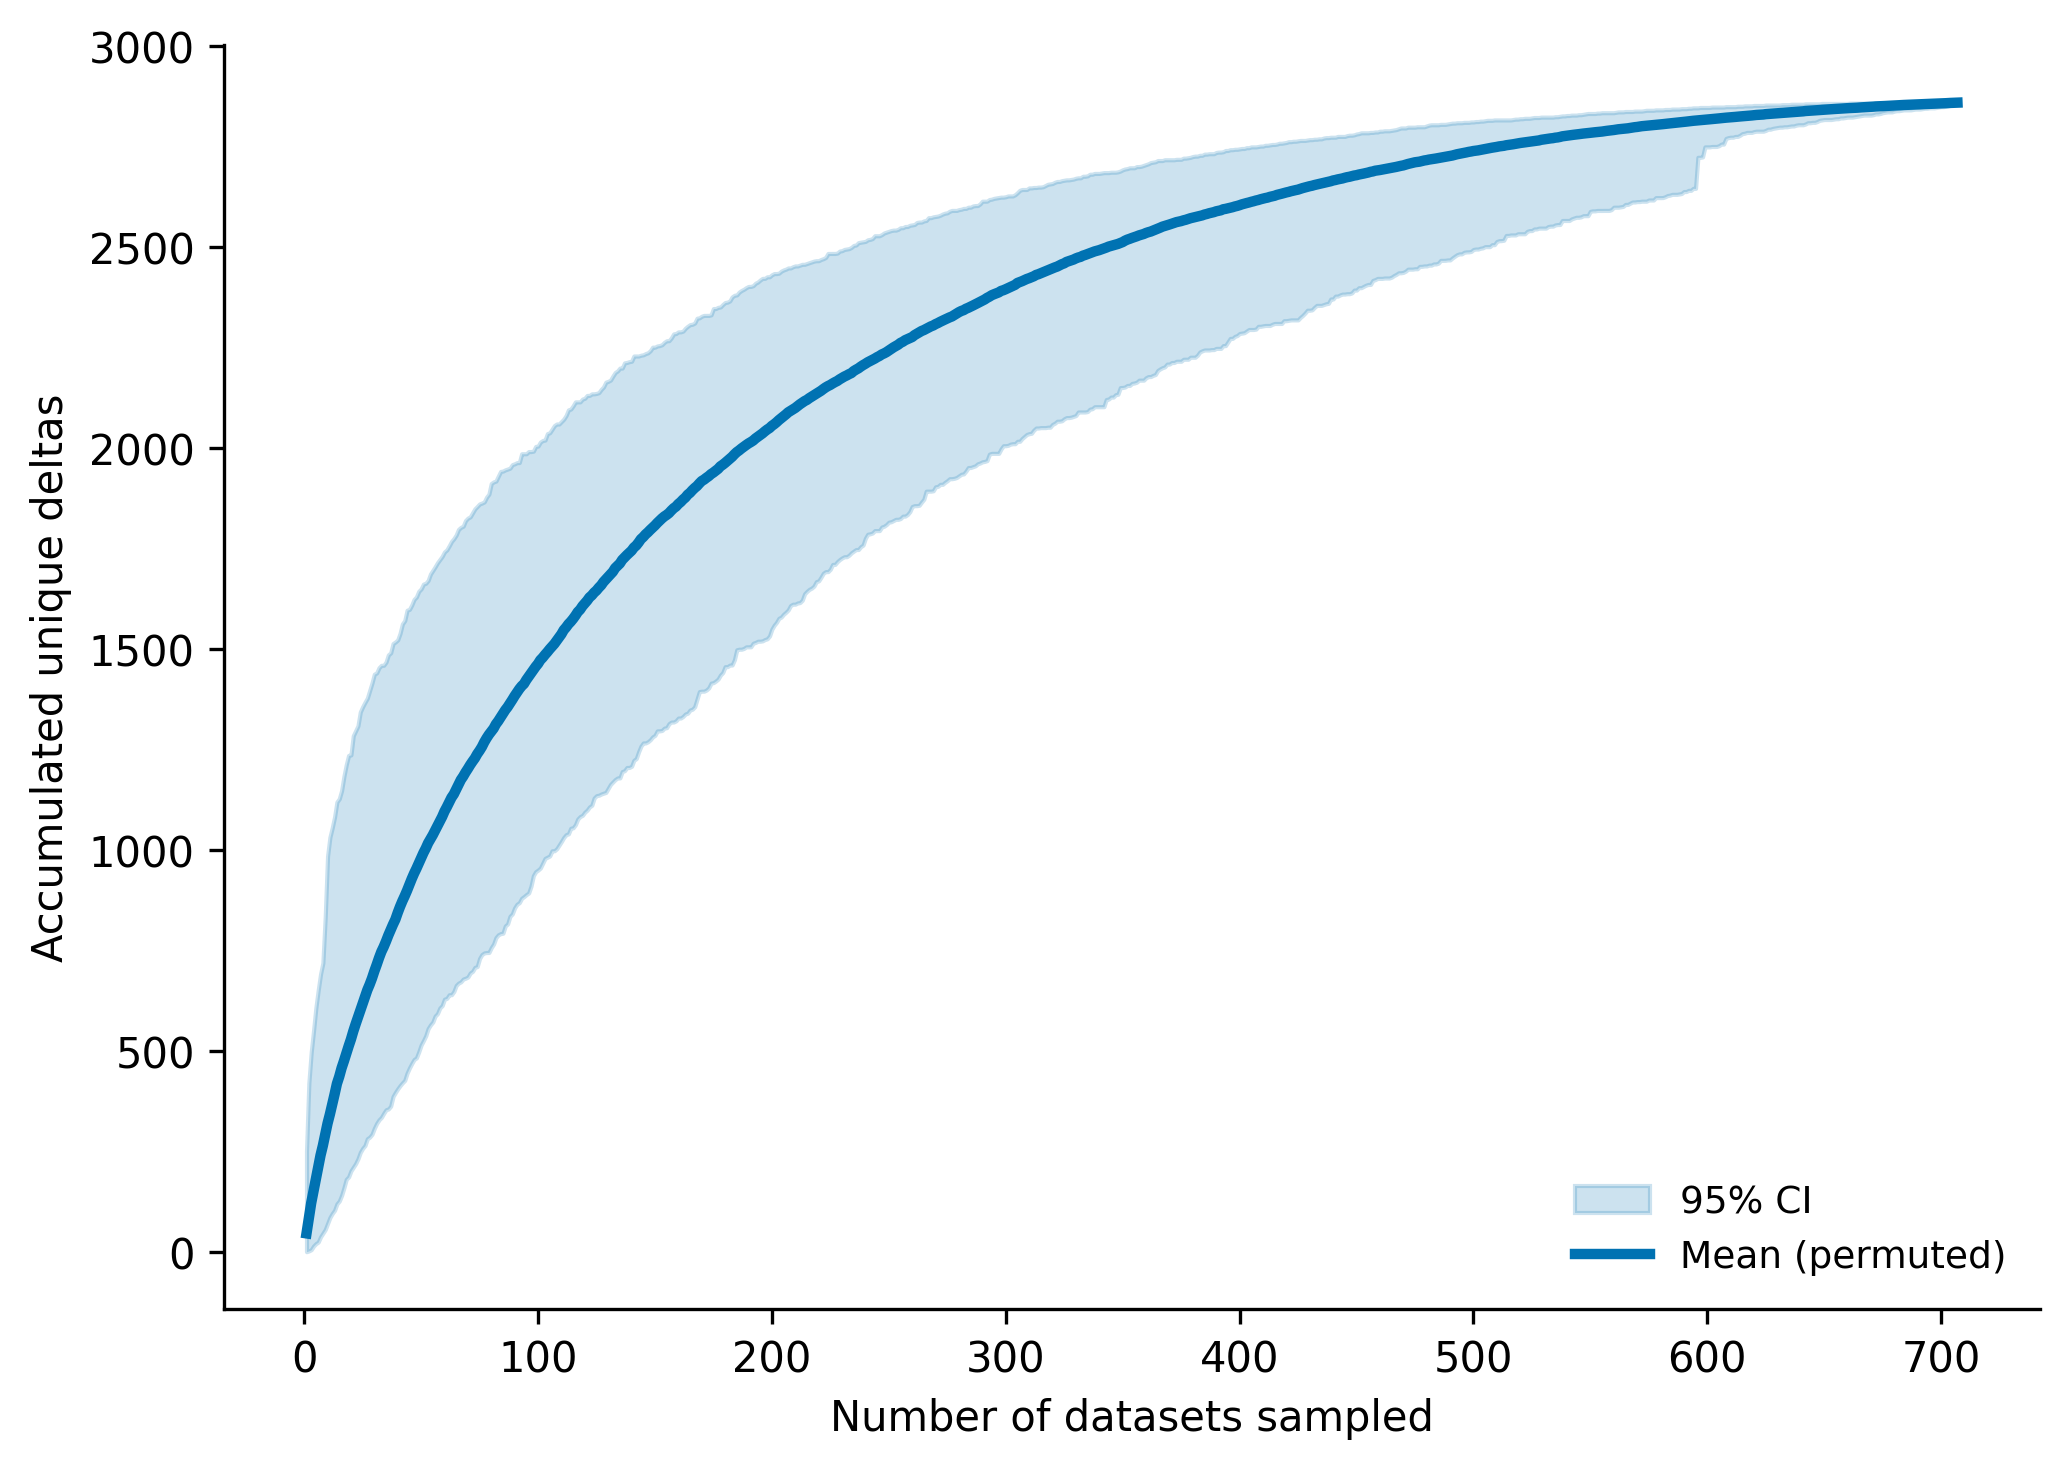

In [19]:
# --- INPUT ---
# df with columns: 'dataset' and 'delta_round_test'

# 1) unique sets per dataset
grp = (df.dropna(subset=['dataset', 'delta_round_test'])
         .groupby('dataset')['delta_round_test']
         .apply(lambda s: set(s.astype(str))))
datasets = grp.index.to_list()
sets = [grp[d] for d in datasets]
n = len(sets)
print(f"N datasets: {n}")

# 2) permutation-based rarefaction
def rarefaction_curve(set_list, n_iter=1000, seed=42):
    rng = default_rng(seed)
    n = len(set_list)
    acc_mat = np.zeros((n_iter, n), dtype=int)
    idx = np.arange(n)
    for it in range(n_iter):
        rng.shuffle(idx)
        seen = set()
        for k, j in enumerate(idx):
            seen |= set_list[j]
            acc_mat[it, k] = len(seen)
    mean = acc_mat.mean(axis=0)
    lo = np.percentile(acc_mat, 2.5, axis=0)
    hi = np.percentile(acc_mat, 97.5, axis=0)
    out = pd.DataFrame({
        'k_datasets': np.arange(1, n+1),
        'unique_deltas_mean': mean,
        'unique_deltas_lo95': lo,
        'unique_deltas_hi95': hi
    })
    return out, acc_mat

rc_df, acc_mat = rarefaction_curve(sets, n_iter=1000, seed=42)

# --- Plot (requested style) ---
# elegant palette (Okabe–Ito blue)
line_color = "#0072B2"   # blue
fill_alpha = 0.20

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# confidence interval
ax.fill_between(rc_df['k_datasets'],
                rc_df['unique_deltas_lo95'],
                rc_df['unique_deltas_hi95'],
                alpha=fill_alpha, label='95% CI',
                color=line_color)

# mean
ax.plot(rc_df['k_datasets'],
        rc_df['unique_deltas_mean'],
        lw=2.5, label='Mean (permuted)',
        color=line_color)

# labels
ax.set_xlabel('Number of datasets sampled')
ax.set_ylabel('Accumulated unique deltas')

# hide top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# legend: bottom-right, smaller, frameless
ax.legend(loc='lower right', frameon=False, fontsize=9)

plt.tight_layout()

fig.savefig("Figure 1d.pdf",
            format="pdf",
            bbox_inches="tight")

plt.show()
